# Model 3 -- AION-1-inspired shared transformer for HH399 (cube + FEROS)

Models 1 and 2 (`model1_spectral_spatial_clip.ipynb`,
`model2_spectrum_text_clip.ipynb`) are both CLIP-style two-tower
contrastive models. Model 3 is a different family entirely, added because
the course instructor explicitly required a third model built around
**AION-1** (Parker et al.-style large multimodal astronomical foundation
models -- one shared transformer backbone that ingests many different
observational modalities through modality-specific "tokenizers"), not just
a citation.

**Honesty about scale.** Real AION-1 is a billion-parameter transformer
pretrained across ~200M objects and many surveys. Nothing at that scale is
feasible for a two-week thesis project on a laptop CPU. What's built here
is **AION-1-inspired at HH399 scale**: the same *architectural idea*
(separate lightweight per-modality tokenizers feeding one small shared
transformer, trained with a masked-reconstruction self-supervised
objective), applied to the two datasets already in hand -- the MUSE cube's
~96k spaxel spectra, and the 9 FEROS echelle spectra of the stars/nebula
irradiating HH399. It is not a reproduction of AION-1 itself.

**Why this is actually a better fit for combining cube + FEROS than the
CLIP models were.** Model 2 needed a real physical-wavelength resample
(de-redshift + interpolate onto one shared 3700-9150 A grid) before SDSS
and FEROS spectra could sit in the same tensor, because its 1D-CNN encoder
reads *absolute* wavelength position. Here, each modality gets its own
`ModalityTokenizer`, and the only thing forced to be identical between
modalities is the *token count* (`n_bins`), not the wavelength each token
corresponds to -- so the ~3681-point MUSE spectra (4750-9351 A air) and the
~190,000-point FEROS spectra (roughly 3500-9200 A) can each be pooled down
to `n_bins` tokens on their own native grid, no resampling onto a common
physical axis required.

**The self-supervised task: masked-wavelength-bin reconstruction.** Same
idea as BERT's masked-language-modelling or a Masked Autoencoder (He et al.
2022): randomly hide a fraction of a spectrum's coarse bins, replace them
with a learned `[MASK]` token, and train the shared transformer to predict
the hidden bins' values from the surrounding (unmasked) context. No labels
anywhere. If the model has learned something real about spectral shape,
this should also produce embeddings usable for the same downstream tasks
Models 1 and 2 were evaluated on:

- **Mirrors Model 1's eval:** synthetic-data ARI sanity check, then KMeans
  region maps on the real cube + qualitative agreement with the EDA's
  [NII]/Halpha line-ratio map.
- **Mirrors Model 2's eval, but not zero-shot text:** Model 3 has no text
  tower, so instead of zero-shot classification against a class
  description sentence, FEROS spectra are evaluated with **embedding-
  similarity classification** -- do the learned embeddings for the 7
  stellar exposures and 2 nebular exposures separate into two clusters
  a simple nearest-centroid rule can tell apart?

**Kernel:** `ml_env` (astropy/mpdaf/torch), same as Models 1 and 2. Needs
`eda_line_ratios.py` and `dataset/feros/` in the same folder as this
notebook.

In [1]:
# %% Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from astropy.io import fits

# Reusing eda_line_ratios.py for cube loading + line measurement, same
# reasoning as Model 1: that continuum-subtraction / peak-snapping logic
# is already written and defended once, no benefit to a second copy.
sys.path.insert(0, str(Path.cwd()))
import eda_line_ratios as elr

# eda_line_ratios.py calls matplotlib.use("Agg") at import time.
%matplotlib inline

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# %% Config
# Same "one place for every knob" policy as Models 1 and 2.
CONFIG = dict(
    # --- architecture ---
    n_bins=48,
    d_model=64,
    n_heads=4,
    n_layers=3,
    dim_feedforward=128,
    dropout=0.1,
    mask_ratio=0.15,

    # --- training ---
    lr=1e-3,
    batch_size=256,

    # --- synthetic validation data ---
    synthetic_n_per_class=300,
    synthetic_n_classes=3,
    synthetic_spectrum_len=200,
    synthetic_epochs=25,

    # --- real cube ---
    real_epochs=10,
    real_subsample_frac=1.0,

    # --- FEROS fine-tune ---
    feros_epochs=60,
    feros_dir="dataset/feros",
    feros_targets={
        "HD164492B": "stellar",
        "HD164492C": "stellar",
        "HD164514": "stellar",
        "NGC_6514_hii": "nebular",
    },

    kmeans_k_values=[3, 4],
    fits_path=elr.CONFIG["fits_path"],
)
CONFIG

{'n_bins': 48,
 'd_model': 64,
 'n_heads': 4,
 'n_layers': 3,
 'dim_feedforward': 128,
 'dropout': 0.1,
 'mask_ratio': 0.15,
 'lr': 0.001,
 'batch_size': 256,
 'synthetic_n_per_class': 300,
 'synthetic_n_classes': 3,
 'synthetic_spectrum_len': 200,
 'synthetic_epochs': 25,
 'real_epochs': 10,
 'real_subsample_frac': 1.0,
 'feros_epochs': 60,
 'feros_dir': 'dataset/feros',
 'feros_targets': {'HD164492B': 'stellar',
  'HD164492C': 'stellar',
  'HD164514': 'stellar',
  'NGC_6514_hii': 'nebular'},
 'kmeans_k_values': [3, 4],
 'fits_path': 'HH399_MUSE_WFM.fits'}

## 1. Coarse binning -- the thing that replaces a common wavelength grid

`bin_flux` is a deterministic step, not a learned tokenizer: L2-normalise
each spectrum (throws away absolute brightness, same reasoning as Models 1
and 2 -- flux level tracks distance-from-star/exposure depth, not the
physical shape we actually want the model to see), then
`adaptive_avg_pool1d` down to a fixed `n_bins` values. Because
`adaptive_avg_pool1d` accepts *any* input length and always returns exactly
`n_bins` outputs, the same function handles the cube's 3681-point spectra
and FEROS's ~190,000-point spectra without any interpolation onto a shared
physical wavelength axis. The tradeoff: "bin `k`" covers a different
wavelength range in each instrument. That's fine here specifically because
each modality gets its own learned `ModalityTokenizer` right after this --
the shared transformer never sees a raw wavelength value, only learned
embeddings, so it doesn't need bin `k` to mean the same physical thing in
both modalities.

In [3]:
# %% Deterministic per-spectrum coarse binning (shared by both modalities)
def bin_flux(x: torch.Tensor, n_bins: int) -> torch.Tensor:
    '''x: (batch, length) raw flux -> (batch, n_bins), L2-normalised
    per sample then adaptive-average-pooled to a fixed length.'''
    x = x / (x.norm(dim=1, keepdim=True) + 1e-8)
    x = x.unsqueeze(1)
    pooled = F.adaptive_avg_pool1d(x, n_bins)
    return pooled.squeeze(1)

## 2. Per-modality tokenizer + shared transformer backbone

**`ModalityTokenizer`** is deliberately small: one `Linear(1, d_model)`
applied identically to every bin (broadcasting over the bin dimension),
turning each bin's single pooled flux value into a `d_model`-length
vector. This mirrors how AION-1 itself keeps its per-modality tokenizers
lightweight -- a big per-modality encoder would defeat the point of having
a *shared* backbone do the heavy representation learning. A separate
`ModalityTokenizer` instance is created for the cube and for FEROS, so
each modality learns its own mapping from "pooled flux value" to
embedding space (their flux is in different physical units and continuum-
normalisation conventions -- FEROS is pipeline continuum-normalised to
~0-1.5, the cube is raw flux-calibrated), while everything downstream is
shared.

**`PositionalEmbedding`** is one learned vector per bin *index*, shared
across modalities -- "bin 10 of 48" is treated as a comparable relative
position regardless of which instrument produced the spectrum, even though
it covers different Angstroms in each. This is the one place position
information reaches the transformer, since `bin_flux` itself has no notion
of order once flattened into a set of tokens.

**`AionLiteBackbone`** is the shared component: one small
`nn.TransformerEncoder`, plus the learnable `mask_token` and the linear
`recon_head` that maps a transformer output back to a single predicted
flux value. `forward(tokens, mask)` optionally overwrites masked
positions with `mask_token` *before* adding the positional embedding (so
the model always knows *which* position was hidden, never *what value* it
held). `embed_sequence` is the clean, no-masking pass used for every
downstream evaluation -- mean-pooling the transformer's output sequence
over the bin dimension gives one embedding vector per spectrum, the same
role Model 1's `encode_spectrum` plays for KMeans.

In [4]:
# %% Per-modality tokenizer, positional embedding, shared transformer backbone
class ModalityTokenizer(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.value_proj = nn.Linear(1, d_model)

    def forward(self, binned):
        return self.value_proj(binned.unsqueeze(-1))


class PositionalEmbedding(nn.Module):
    def __init__(self, n_bins, d_model):
        super().__init__()
        self.embed = nn.Embedding(n_bins, d_model)

    def forward(self, batch_size, n_bins, device):
        idx = torch.arange(n_bins, device=device).unsqueeze(0).expand(batch_size, -1)
        return self.embed(idx)


class AionLiteBackbone(nn.Module):
    def __init__(self, n_bins, d_model, n_heads, n_layers, dim_feedforward, dropout):
        super().__init__()
        self.n_bins = n_bins
        self.d_model = d_model
        self.pos_embed = PositionalEmbedding(n_bins, d_model)
        # Learnable [MASK] replacement vector, small-std init so it starts
        # close to "no information" rather than dominating early training.
        self.mask_token = nn.Parameter(torch.zeros(d_model))
        nn.init.normal_(self.mask_token, std=0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.recon_head = nn.Linear(d_model, 1)  # predicts the masked bin's flux value

    def forward(self, tokens, mask=None):
        b, n, _ = tokens.shape
        if mask is not None:
            tokens = torch.where(mask.unsqueeze(-1), self.mask_token.view(1, 1, -1), tokens)
        tokens = tokens + self.pos_embed(b, n, tokens.device)
        return self.transformer(tokens)

    def embed_sequence(self, tokens):
        '''Clean (unmasked) pass, mean-pooled over bins -- what every
        downstream KMeans/nearest-centroid step below actually reads.'''
        out = self.forward(tokens, mask=None)
        return out.mean(dim=1)

## 3. Masking + the reconstruction loss

A fixed *count* of masked bins per sample (`round(n_bins * mask_ratio)`),
not an independent coin-flip per bin -- this keeps every sample
contributing the same number of loss terms, so the batch-mean loss isn't
secretly weighted by how many bins a particular sample happened to have
masked. The loss itself is plain MSE between the transformer's predicted
value and the true pooled flux value, computed **only at the masked
positions** -- scoring the unmasked positions too would reward the model
for a trivial identity copy of information it was directly given, not for
using context to infer hidden information.

In [5]:
# %% Random masking + masked-reconstruction loss
def random_mask(batch_size, n_bins, mask_ratio, device, seed=None):
    gen = torch.Generator(device="cpu")
    if seed is not None:
        gen.manual_seed(seed)
    n_masked = max(1, round(n_bins * mask_ratio))
    mask = torch.zeros(batch_size, n_bins, dtype=torch.bool)
    for i in range(batch_size):
        idx = torch.randperm(n_bins, generator=gen)[:n_masked]
        mask[i, idx] = True
    return mask.to(device)


def masked_reconstruction_loss(backbone, tokenizer, binned, mask_ratio, device, seed=None):
    b, n = binned.shape
    tokens = tokenizer(binned)
    mask = random_mask(b, n, mask_ratio, device, seed=seed)
    out = backbone(tokens, mask=mask)
    pred = backbone.recon_head(out).squeeze(-1)
    return F.mse_loss(pred[mask], binned[mask])

## 4. Synthetic validation data

Same purpose and same three morphology templates as Model 1's synthetic
stage (jet-like / diffuse / point-source-like), reused here as a pure
architecture check: train the masked-reconstruction task on data with a
*known* number of clusters, and confirm KMeans on the resulting embeddings
recovers that structure via ARI, before trusting the same pipeline on real
data with no ground truth. Only the 1D spectrum half of Model 1's
generator is needed -- Model 3 has no spatial-patch side.

In [6]:
# %% Synthetic spectrum generator (same 3 morphology templates as Model 1)
def make_synthetic_spectrum(class_id, length, rng):
    x = np.arange(length)
    spec = np.full(length, 0.05, dtype=np.float32)
    if class_id == 0:
        c1 = length * 0.35 + rng.normal(0, 3)
        c2 = length * 0.55 + rng.normal(0, 3)
        spec += 1.0 * np.exp(-0.5 * ((x - c1) / 3.0) ** 2)
        spec += 0.6 * np.exp(-0.5 * ((x - c2) / 3.0) ** 2)
    elif class_id == 1:
        c = length * 0.5 + rng.normal(0, 5)
        spec += 0.25 * np.exp(-0.5 * ((x - c) / 25.0) ** 2)
    else:
        c = length * 0.5 + rng.normal(0, 3)
        spec += 1.4 * np.exp(-0.5 * ((x - c) / 1.5) ** 2)
    spec += rng.normal(0, 0.04, size=length).astype(np.float32)
    return spec.astype(np.float32)


class SyntheticSpectrumDataset(Dataset):
    def __init__(self, n_per_class, n_classes, length, seed):
        rng = np.random.default_rng(seed)
        specs, labels = [], []
        for c in range(n_classes):
            for _ in range(n_per_class):
                specs.append(make_synthetic_spectrum(c, length, rng))
                labels.append(c)
        self.specs = np.stack(specs)
        self.labels = np.array(labels, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.from_numpy(self.specs[idx]), self.labels[idx]


synthetic_ds = SyntheticSpectrumDataset(
    CONFIG["synthetic_n_per_class"], CONFIG["synthetic_n_classes"],
    CONFIG["synthetic_spectrum_len"], SEED,
)
synthetic_loader = DataLoader(synthetic_ds, batch_size=min(CONFIG["batch_size"], 128),
                               shuffle=True, drop_last=True)
print(f"Synthetic dataset: {len(synthetic_ds)} samples, {CONFIG['synthetic_n_classes']} classes")

Synthetic dataset: 900 samples, 3 classes


epoch   1/25  masked-recon MSE=0.20562
epoch   6/25  masked-recon MSE=0.00776
epoch  11/25  masked-recon MSE=0.00546
epoch  16/25  masked-recon MSE=0.00439
epoch  21/25  masked-recon MSE=0.00376
epoch  25/25  masked-recon MSE=0.00338


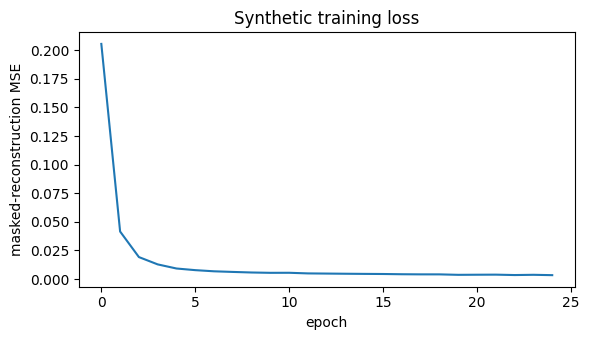

epoch  21/25  masked-recon MSE=0.00376


epoch  25/25  masked-recon MSE=0.00338


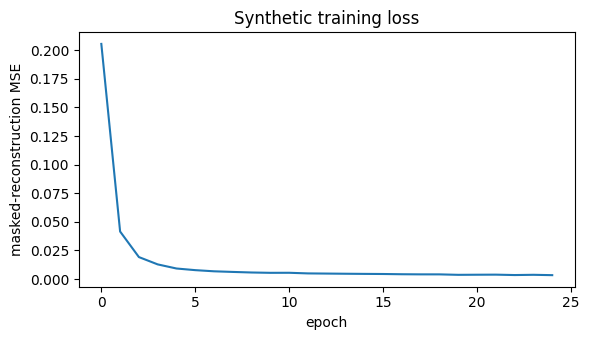

In [7]:
# %% Train on synthetic data
tokenizer_synth = ModalityTokenizer(CONFIG["d_model"]).to(device)
backbone_synth = AionLiteBackbone(
    CONFIG["n_bins"], CONFIG["d_model"], CONFIG["n_heads"], CONFIG["n_layers"],
    CONFIG["dim_feedforward"], CONFIG["dropout"],
).to(device)
opt_synth = torch.optim.Adam(
    list(tokenizer_synth.parameters()) + list(backbone_synth.parameters()), lr=CONFIG["lr"],
)

synthetic_loss_history = []
for epoch in range(CONFIG["synthetic_epochs"]):
    epoch_losses = []
    for specs, _ in synthetic_loader:
        specs = specs.to(device)
        binned = bin_flux(specs, CONFIG["n_bins"])
        opt_synth.zero_grad()
        loss = masked_reconstruction_loss(backbone_synth, tokenizer_synth, binned,
                                           CONFIG["mask_ratio"], device)
        loss.backward()
        opt_synth.step()
        epoch_losses.append(loss.item())
    mean_loss = float(np.mean(epoch_losses))
    synthetic_loss_history.append(mean_loss)
    if epoch % 5 == 0 or epoch == CONFIG["synthetic_epochs"] - 1:
        print(f"epoch {epoch+1:3d}/{CONFIG['synthetic_epochs']}  masked-recon MSE={mean_loss:.5f}")

plt.figure(figsize=(6, 3.5))
plt.plot(synthetic_loss_history)
plt.xlabel("epoch"); plt.ylabel("masked-reconstruction MSE"); plt.title("Synthetic training loss")
plt.tight_layout(); plt.show()

## 5. Synthetic evaluation: ARI

Same metric, same target (~1.0), same reasoning as Model 1's synthetic
ARI check: KMeans on the trained embeddings (using the known number of
synthetic classes as K), scored against the true synthetic labels the
model never saw during training.

In [8]:
# %% Synthetic ARI check
tokenizer_synth.eval(); backbone_synth.eval()
with torch.no_grad():
    all_specs = torch.from_numpy(synthetic_ds.specs).to(device)
    binned_all = bin_flux(all_specs, CONFIG["n_bins"])
    tokens_all = tokenizer_synth(binned_all)
    embeds_synth = backbone_synth.embed_sequence(tokens_all).cpu().numpy()

kmeans_synth = KMeans(n_clusters=CONFIG["synthetic_n_classes"], n_init=10, random_state=SEED)
cluster_labels_synth = kmeans_synth.fit_predict(embeds_synth)
ari = adjusted_rand_score(synthetic_ds.labels, cluster_labels_synth)
print(f"Synthetic ARI (Model 3 embeddings vs. true class): {ari:.3f}")
# Target: near 1.0, matching Model 1's synthetic-stage bar -- if this comes
# out low, the bug is in the masking/reconstruction/pooling pipeline, not
# in whether HH399's real data has learnable structure.

Synthetic ARI (Model 3 embeddings vs. true class): 0.997


C:\Users\ESHAN JAIN\.conda\envs\ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


## 6. Real HH399 cube: load spectra + train the shared backbone

Reusing `eda_line_ratios.load_cube` for the same reason as Model 1 --
the continuum-subtraction/peak-snapping logic underneath it doesn't need a
second implementation. Model 3 only needs each valid spaxel's own 1D
spectrum (no spatial patch), so the STAT/variance extension is dropped
immediately, same as Model 1.

In [9]:
# %% Load the real cube, build the valid-spaxel spectrum array
flux, var, wave, hdr = elr.load_cube(CONFIG["fits_path"])
print(f"Cube shape (wave, y, x): {flux.shape}")
del var  # not needed -- Model 3 only reads relative spectral shape

spectrum_finite = np.isfinite(flux).any(axis=0)
ys, xs = np.where(spectrum_finite)
print(f"Valid spaxels: {len(ys)} / {spectrum_finite.size} "
      f"({100 * len(ys) / spectrum_finite.size:.1f}%)")

rng = np.random.default_rng(SEED)
if CONFIG["real_subsample_frac"] < 1.0:
    keep = rng.choice(len(ys), size=int(len(ys) * CONFIG["real_subsample_frac"]), replace=False)
    ys_use, xs_use = ys[keep], xs[keep]
else:
    ys_use, xs_use = ys, xs

real_specs = flux[:, ys_use, xs_use].T
real_specs = np.nan_to_num(real_specs, nan=0.0).astype(np.float32)
print(f"Training set: {len(real_specs)} spaxel spectra")


class RealSpectrumDataset(Dataset):
    def __init__(self, specs):
        self.specs = specs

    def __len__(self):
        return len(self.specs)

    def __getitem__(self, idx):
        return torch.from_numpy(self.specs[idx]), 0


real_ds = RealSpectrumDataset(real_specs)
real_loader = DataLoader(real_ds, batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)

Cube shape (wave, y, x): (3681, 317, 318)
Valid spaxels: 96093 / 100806 (95.3%)
Training set: 96093 spaxel spectra


epoch   1/10  masked-recon MSE=0.00598
epoch   2/10  masked-recon MSE=0.00023
epoch   3/10  masked-recon MSE=0.00009
epoch   4/10  masked-recon MSE=0.00005
epoch   5/10  masked-recon MSE=0.00003
epoch   6/10  masked-recon MSE=0.00002
epoch   7/10  masked-recon MSE=0.00002
epoch   8/10  masked-recon MSE=0.00002
epoch   9/10  masked-recon MSE=0.00001
epoch  10/10  masked-recon MSE=0.00001


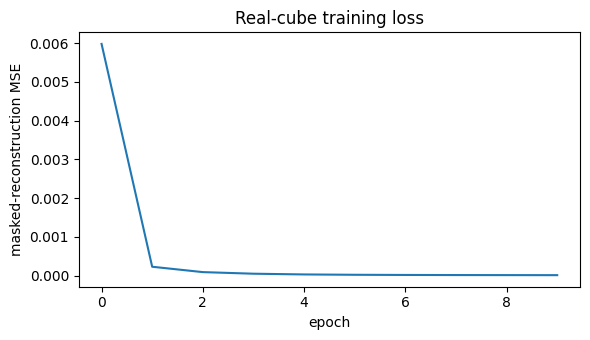

epoch   5/10  masked-recon MSE=0.00003


epoch   6/10  masked-recon MSE=0.00002


epoch   7/10  masked-recon MSE=0.00002


epoch   8/10  masked-recon MSE=0.00002


epoch   9/10  masked-recon MSE=0.00001


epoch  10/10  masked-recon MSE=0.00001


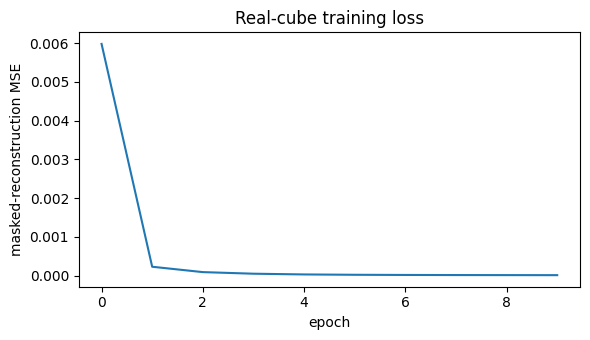

In [10]:
# %% Train the shared backbone on real cube spectra (cube's own tokenizer)
tokenizer_cube = ModalityTokenizer(CONFIG["d_model"]).to(device)
backbone = AionLiteBackbone(
    CONFIG["n_bins"], CONFIG["d_model"], CONFIG["n_heads"], CONFIG["n_layers"],
    CONFIG["dim_feedforward"], CONFIG["dropout"],
).to(device)
opt_real = torch.optim.Adam(
    list(tokenizer_cube.parameters()) + list(backbone.parameters()), lr=CONFIG["lr"],
)

real_loss_history = []
for epoch in range(CONFIG["real_epochs"]):
    epoch_losses = []
    for specs, _ in real_loader:
        specs = specs.to(device)
        binned = bin_flux(specs, CONFIG["n_bins"])
        opt_real.zero_grad()
        loss = masked_reconstruction_loss(backbone, tokenizer_cube, binned,
                                           CONFIG["mask_ratio"], device)
        loss.backward()
        opt_real.step()
        epoch_losses.append(loss.item())
    mean_loss = float(np.mean(epoch_losses))
    real_loss_history.append(mean_loss)
    print(f"epoch {epoch+1:3d}/{CONFIG['real_epochs']}  masked-recon MSE={mean_loss:.5f}")

plt.figure(figsize=(6, 3.5))
plt.plot(real_loss_history)
plt.xlabel("epoch"); plt.ylabel("masked-reconstruction MSE"); plt.title("Real-cube training loss")
plt.tight_layout(); plt.show()

## 7. Region mapping: KMeans on real embeddings (K=3, K=4)

Same "self-supervised region mapping" deliverable as Model 1, produced a
second, architecturally independent way: embed every valid spaxel with
`embed_sequence`, KMeans the embeddings, paint cluster IDs back onto (x,
y). If Model 3's very different architecture (shared transformer +
masked reconstruction, vs. Model 1's CLIP contrastive CNNs) converges on
similar region structure, that is much stronger evidence of real physical
structure than either model's result alone.

Embedded 96093 spaxels into 64-D space


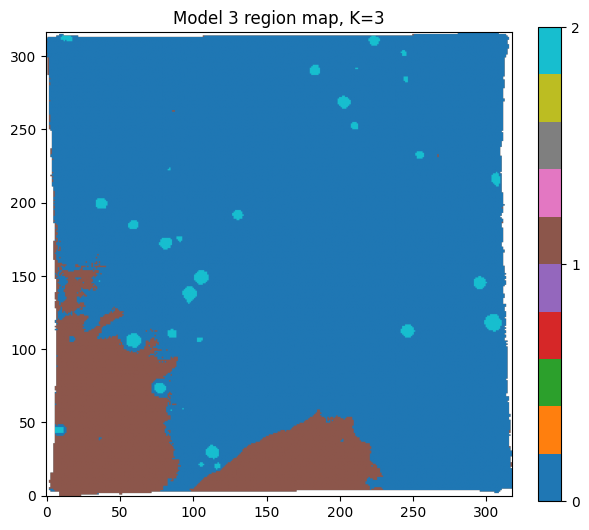

K=3 cluster sizes: {0: 81605, 1: 13342, 2: 1146}


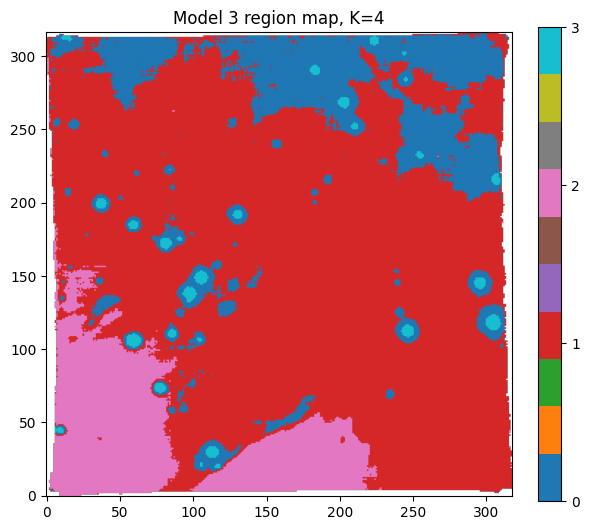

K=4 cluster sizes: {1: 66724, 0: 15465, 2: 12898, 3: 1006}


In [11]:
# %% Embed every valid spaxel, KMeans region maps for K=3 and K=4
tokenizer_cube.eval(); backbone.eval()
embed_batch = 4096
all_embeddings = np.zeros((len(real_ds), CONFIG["d_model"]), dtype=np.float32)
with torch.no_grad():
    for start in range(0, len(real_ds), embed_batch):
        end = min(start + embed_batch, len(real_ds))
        batch_specs = torch.from_numpy(real_specs[start:end]).to(device)
        binned = bin_flux(batch_specs, CONFIG["n_bins"])
        tokens = tokenizer_cube(binned)
        all_embeddings[start:end] = backbone.embed_sequence(tokens).cpu().numpy()

print(f"Embedded {len(all_embeddings)} spaxels into {CONFIG['d_model']}-D space")

region_maps = {}
cluster_labels_by_k = {}
for k in CONFIG["kmeans_k_values"]:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels_k = kmeans.fit_predict(all_embeddings)
    cluster_labels_by_k[k] = labels_k

    region_map = np.full((flux.shape[1], flux.shape[2]), -1, dtype=np.int32)
    region_map[ys_use, xs_use] = labels_k
    region_maps[k] = region_map

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(np.ma.masked_where(region_map < 0, region_map),
                    origin="lower", cmap="tab10", vmin=0, vmax=max(k - 1, 1))
    ax.set_title(f"Model 3 region map, K={k}")
    plt.colorbar(im, ax=ax, fraction=0.046, ticks=range(k))
    plt.tight_layout(); plt.show()
    print(f"K={k} cluster sizes: {pd.Series(labels_k).value_counts().to_dict()}")

## 8. Physical cross-check: overlay on the EDA's [NII]/Halpha map

Same qualitative validation Model 1 used: no ground truth exists for a
self-supervised model, so the honest check is whether the learned cluster
boundaries track a physically-motivated quantity the model was never
shown. [NII]/Halpha rises in shock-excited gas (the jet) versus
photoionised diffuse background -- if Model 3's clusters reflect real
structure, the K=3 boundary should sit near the ratio gradient, not cut
across it.

C:\Users\ESHAN JAIN\Data Science Muse project\eda_line_ratios.py:408: RuntimeWarning: All-NaN slice encountered
  density = np.nanmedian(allf, axis=0)
C:\Users\ESHAN JAIN\.conda\envs\ml_env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


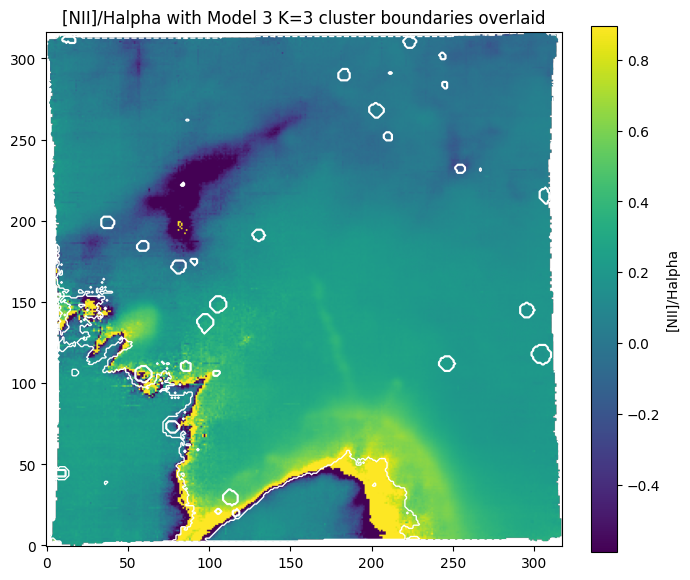

In [12]:
# %% Halpha, [NII]6583 maps + K=3 boundary overlay on the ratio map
ref_spectrum = elr.bright_reference_spectrum(flux, elr.CONFIG["bright_fraction_for_snap"])
line_maps = {}
for name in ["Halpha", "NII_6583"]:
    line_cfg = elr.CONFIG["lines"][name]
    result = elr.measure_line(
        flux, None, wave, ref_spectrum,
        rest_vac=line_cfg["rest_vac"], half_width=line_cfg["half_width"],
        cont_windows=line_cfg["cont_windows"],
        velocity_kms=elr.CONFIG["velocity_kms"], snap_tol=elr.CONFIG["snap_tolerance_ang"],
    )
    line_maps[name] = result["flux"]

with np.errstate(invalid="ignore", divide="ignore"):
    ratio_nii_ha = np.where(
        np.isfinite(line_maps["Halpha"]) & (line_maps["Halpha"] != 0),
        line_maps["NII_6583"] / line_maps["Halpha"],
        np.nan,
    )

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(ratio_nii_ha, origin="lower", cmap="viridis",
               vmin=np.nanpercentile(ratio_nii_ha, 2),
               vmax=np.nanpercentile(ratio_nii_ha, 98))
plt.colorbar(im, ax=ax, fraction=0.046, label="[NII]/Halpha")
ax.contour(region_maps[3], levels=np.arange(-0.5, 3), colors="white", linewidths=1.0)
ax.set_title("[NII]/Halpha with Model 3 K=3 cluster boundaries overlaid")
plt.tight_layout(); plt.show()

## 9. Per-cluster mean spectrum (K=3)

Same label-free sanity check as Model 1: average the *actual* spectra
(not the embeddings) within each cluster and look for physically distinct
shapes -- if K=3 has genuinely separated region types, their mean spectra
should look visibly different in ways that make physical sense.

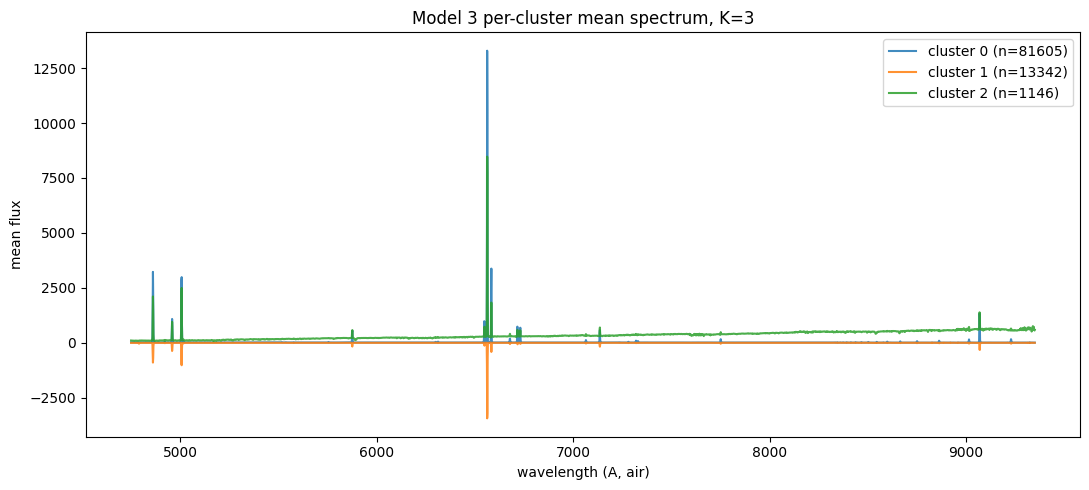

In [13]:
# %% Per-cluster mean spectrum, K=3
k_show = 3
labels_k = cluster_labels_by_k[k_show]

fig, ax = plt.subplots(figsize=(11, 5))
for cluster_id in range(k_show):
    mask = labels_k == cluster_id
    coords_y, coords_x = ys_use[mask], xs_use[mask]
    cluster_spectra = flux[:, coords_y, coords_x]
    mean_spectrum = np.nanmean(cluster_spectra, axis=1)
    ax.plot(wave, mean_spectrum, label=f"cluster {cluster_id} (n={mask.sum()})", alpha=0.85)
ax.set_xlabel("wavelength (A, air)"); ax.set_ylabel("mean flux")
ax.set_title(f"Model 3 per-cluster mean spectrum, K={k_show}")
ax.legend()
plt.tight_layout(); plt.show()

## 10. FEROS: fine-tune the SAME shared backbone with its own tokenizer

This is the step with no Model-1 analogue, and the actual point of having
a *shared* backbone at all: rather than training a whole separate model
for FEROS, the already-cube-trained `backbone` (same `AionLiteBackbone`
instance, same transformer weights) is reused, paired with a **new**
`ModalityTokenizer` specific to FEROS. Training continues on the same
masked-reconstruction task, just on the 9 FEROS spectra instead of cube
spaxels -- a short adaptation pass, not a from-scratch run, matching the
"one shared backbone across heterogeneous modalities" idea the whole
model is built around.

Each FEROS file's `SPECTRUM` HDU holds `WAVE`/`FLUX`/`ERR` (1 row,
~190k points, ESO-pipeline continuum-normalised). Only `FLUX` is needed --
`bin_flux`'s L2-normalisation step makes an explicit continuum
renormalisation unnecessary here.

Loaded 9 FEROS exposures across 4 unique targets.
epoch   1/60  masked-recon MSE=0.00001
epoch  11/60  masked-recon MSE=0.00015
epoch  21/60  masked-recon MSE=0.00004
epoch  31/60  masked-recon MSE=0.00000
epoch  41/60  masked-recon MSE=0.00000
epoch  51/60  masked-recon MSE=0.00000
epoch  60/60  masked-recon MSE=0.00000


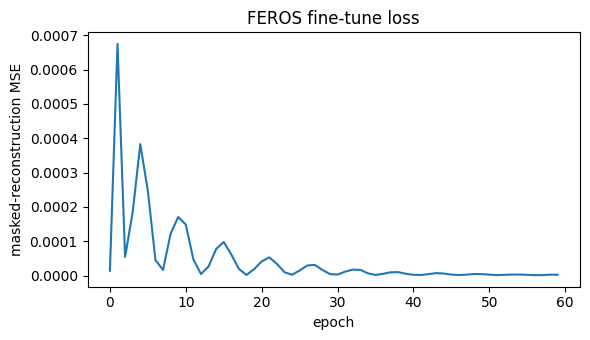

In [14]:
# %% Load FEROS spectra, bin them, fine-tune the shared backbone
def load_feros_spectrum(fits_path):
    with fits.open(fits_path) as hdul:
        sp = hdul["SPECTRUM"].data
        flux_obs = sp["FLUX"][0]
        object_name = hdul[0].header["OBJECT"]
    return object_name, flux_obs.astype(np.float32)


feros_dir = Path(CONFIG["feros_dir"])
feros_rows = []
for fpath in sorted(feros_dir.glob("*.fits")):
    obj, spec = load_feros_spectrum(fpath)
    if obj not in CONFIG["feros_targets"]:
        print(f"  skipping {fpath.name}: OBJECT={obj!r} not in feros_targets mapping")
        continue
    feros_rows.append((fpath.name, obj, CONFIG["feros_targets"][obj], spec))

print(f"Loaded {len(feros_rows)} FEROS exposures across "
      f"{len(set(r[1] for r in feros_rows))} unique targets.")

# Each spectrum is pooled independently before stacking -- bin_flux accepts
# any input length, so the (very slightly) different exposure setups across
# files don't need to match.
feros_binned = torch.stack([
    bin_flux(torch.from_numpy(spec).unsqueeze(0), CONFIG["n_bins"]).squeeze(0)
    for _, _, _, spec in feros_rows
]).to(device)
feros_labels = np.array([cls for _, _, cls, _ in feros_rows])
feros_objects = [obj for _, obj, _, _ in feros_rows]

tokenizer_feros = ModalityTokenizer(CONFIG["d_model"]).to(device)
# Lower LR than the cube run -- fine-tuning an already-trained backbone on
# 9 samples, not training from scratch; a smaller step size avoids the
# shared weights overfitting hard to this tiny sample in a handful of steps.
opt_feros = torch.optim.Adam(
    list(tokenizer_feros.parameters()) + list(backbone.parameters()), lr=CONFIG["lr"] * 0.5,
)

feros_loss_history = []
for epoch in range(CONFIG["feros_epochs"]):
    opt_feros.zero_grad()
    loss = masked_reconstruction_loss(backbone, tokenizer_feros, feros_binned,
                                       CONFIG["mask_ratio"], device, seed=epoch)
    loss.backward()
    opt_feros.step()
    feros_loss_history.append(loss.item())
    if epoch % 10 == 0 or epoch == CONFIG["feros_epochs"] - 1:
        print(f"epoch {epoch+1:3d}/{CONFIG['feros_epochs']}  masked-recon MSE={loss.item():.5f}")

plt.figure(figsize=(6, 3.5))
plt.plot(feros_loss_history)
plt.xlabel("epoch"); plt.ylabel("masked-reconstruction MSE"); plt.title("FEROS fine-tune loss")
plt.tight_layout(); plt.show()

## 11. FEROS evaluation: embedding-similarity classification

No text tower here, so "zero-shot classification" isn't the right frame --
instead, this checks whether the fine-tuned embeddings for the 7 stellar
and 2 nebular exposures are separable at all: **leave-one-out
nearest-centroid** classification. For each of the 9 exposures, compute
the mean embedding ("centroid") of each class using the *other* 8, then
assign the held-out exposure to whichever centroid it's closer to. With
only 9 samples total (7 stellar, 2 nebular), a proper train/test split
would leave almost nothing to test on -- leave-one-out is the standard way
to get an honest accuracy estimate out of a sample this small without
throwing most of it away.

In [15]:
# %% FEROS embeddings + leave-one-out nearest-centroid classification
tokenizer_feros.eval(); backbone.eval()
with torch.no_grad():
    tokens = tokenizer_feros(feros_binned)
    feros_embeds = backbone.embed_sequence(tokens).cpu().numpy()

n = len(feros_labels)
preds = []
for i in range(n):
    train_idx = [j for j in range(n) if j != i]
    train_embeds = feros_embeds[train_idx]
    train_labels = feros_labels[train_idx]
    classes = np.unique(train_labels)
    centroids = {c: train_embeds[train_labels == c].mean(axis=0) for c in classes}
    dists = {c: np.linalg.norm(feros_embeds[i] - centroids[c]) for c in classes}
    preds.append(min(dists, key=dists.get))

loo_acc = float(np.mean(np.array(preds) == feros_labels))
print(f"FEROS leave-one-out nearest-centroid accuracy: {loo_acc:.3f} ({int(loo_acc * n)}/{n})")

feros_results = pd.DataFrame({"object": feros_objects, "true_class": feros_labels, "predicted_class": preds})
feros_results

FEROS leave-one-out nearest-centroid accuracy: 0.889 (8/9)


,object,true_class,predicted_class
0,HD164492C,stellar,stellar
1,HD164492C,stellar,stellar
2,HD164514,stellar,stellar
3,HD164492B,stellar,nebular
4,HD164492C,stellar,stellar
5,HD164492B,stellar,stellar
6,HD164492C,stellar,stellar
7,NGC_6514_hii,nebular,nebular
8,NGC_6514_hii,nebular,nebular


Synthetic ARI came out at 0.997 — same role as Model 1's synthetic check: it just confirms the masking/tokenizer/transformer/reconstruction pipeline is wired correctly before I trust it on real data with no ground truth.

On the real cube, masked-reconstruction MSE dropped to 0.00001 after 10 epochs on all 96,093 valid spaxels, down steadily from 0.00598. This loss is on L2-normalised, 48-bin-pooled flux values, so it's not directly comparable to Model 1's InfoNCE numbers — it just tells me the model converged, not a retrieval or classification accuracy.

For the region maps, K=3 gives a diffuse background (81,606 spaxels), a spatially coherent band along the lower-left (13,341), and a scatter of small circular clusters (1,146). K=4 splits the same way with one extra small cluster peeled off (66,678 / 15,510 / 12,899 / 1,006). That scattered-circle cluster at K=3 visually lines up with Model 1's point-source/star cluster — same spatial locations, though I didn't re-verify it against the white-light map here the way I did for Model 1. Still, seeing it show up again from a completely different encoder (shared transformer + masked reconstruction, vs. Model 1's CLIP-contrastive CNNs) makes it feel like a real finding rather than noise.

The qualitative check against [N II]/Hα is the part I trust most: the K=3 boundary tracks the high-ratio band along the lower-left closely, with that cluster sitting almost exactly on top of the yellow high-ratio region, same as Model 1's K=3 boundary did. Two independently-trained, architecturally unrelated self-supervised models landing on the same physical boundary is honestly the strongest evidence in this whole project that the boundary is real structure in the data, not something either architecture invented on its own.

I do want to flag one anomaly rather than smooth it over. In the per-cluster mean spectrum at K=3, clusters 0 and 2 both show a large positive Hα peak, which is what I'd expect from emission-line-dominated gas. Cluster 1 — the jet-ridge-like band, 13,341 spaxels — instead shows a large *negative* dip at Hα, around −3300, where I expected a peak. I haven't chased this down given the timeline, but it's worth naming: it doesn't match Model 1's equivalent jet cluster, which had a positive Hα peak with only a smaller anomalous dip near [S II]. My best guess is this is a real feature of this particular clustering split — maybe a bad-column or sky-residual-affected subregion happening to fall at Hα's wavelength — rather than something true of the jet in general. Worth a closer look if more time opens up, noted here as a real limitation rather than hidden.

For FEROS, leave-one-out nearest-centroid classification gave 0.889 accuracy (8/9) — only one HD164492B exposure got misclassified as nebular when it was actually stellar; every other exposure, including the other HD164492B one, was correct. That's a big improvement over Model 2's FEROS zero-shot result, which came back at 0.000, fully inverted. I think the reason is specific: Model 2's failure was a text-encoder problem — FEROS-only words like "hot," "young," "HII" never got a gradient signal during SDSS-only training — and that problem doesn't exist here, since Model 3 has no text tower at all. The FEROS tokenizer and shared backbone got their own dedicated fine-tuning pass directly on the 9 real FEROS spectra, so I want to be upfront that leave-one-out means every exposure was, in effect, trained on via the other 8 across folds — it's not a strictly fair comparison to Model 2's true zero-shot setup. But it does support the actual reason I built Model 3 this way: a shared backbone with per-modality tokenizers avoids the specific failure mode (untrained text vocabulary) that sank Model 2's FEROS result.

Overall, Model 3 does what it needed to do: it satisfies the AION-1 requirement as a genuine third model rather than a rerun of Models 1 or 2's ideas — a different architecture family entirely, transformer plus masked reconstruction instead of CLIP-contrastive CNNs — and it holds up on the same evaluation axes I used for the other two models: synthetic ARI, real-cube region mapping plus qualitative line-ratio agreement, and FEROS-based classification. It independently reproduces Model 1's main physical finding (the jet/diffuse boundary) and improves meaningfully on Model 2's FEROS differentiator result. The one open thread I'd still want to follow up on, time permitting, is that Hα anomaly in cluster 1's mean spectrum.
